# 🧠 Deep Learning Embedding for Fingerprint Verification

This notebook demonstrates Phase 3.3 (Deep Learning Embedding) using a Siamese CNN trained on the SOCOFing dataset.

In [1]:
import os
import sys
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_extraction.embedding import SiameseNetwork, extract_embedding

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing'
MODEL_PATH = PROJECT_ROOT / 'models' / 'siamese_model.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Model and Initialize Pipeline

In [2]:
# Load model
model = SiameseNetwork(embedding_dim=128, pretrained=False).to(device)
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("Loaded trained weights.")
else:
    print("Warning: Trained weights not found. Using untrained ResNet.")
    
model.eval()

# Transformation pipeline (matches training)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_transform(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    tensor = transform(img_rgb)
    return img, tensor

C:\Users\Avani\OneDrive\Desktop\fingerprint\env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Avani\OneDrive\Desktop\fingerprint\env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded trained weights.


## 2. Extract Embeddings & Compute Distances

In [3]:
def compare_pair(path1, path2, is_genuine):
    img1_cv, tensor1 = load_and_transform(path1)
    img2_cv, tensor2 = load_and_transform(path2)
    
    emb1 = extract_embedding(model, tensor1, device)
    emb2 = extract_embedding(model, tensor2, device)
    
    distance = F.pairwise_distance(emb1, emb2).item()
    cos_sim = F.cosine_similarity(emb1, emb2).item()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    title = f"{'Genuine' if is_genuine else 'Impostor'} Pair\nDistance: {distance:.3f} | Cosine Sim: {cos_sim:.3f}"
    fig.suptitle(title, fontsize=14, fontweight='bold', color='green' if is_genuine else 'red')
    
    axes[0].imshow(img1_cv, cmap='gray')
    axes[0].set_title("Image 1")
    axes[0].axis('off')
    
    axes[1].imshow(img2_cv, cmap='gray')
    axes[1].set_title("Image 2")
    axes[1].axis('off')
    
    plt.tight_layout()
    return fig

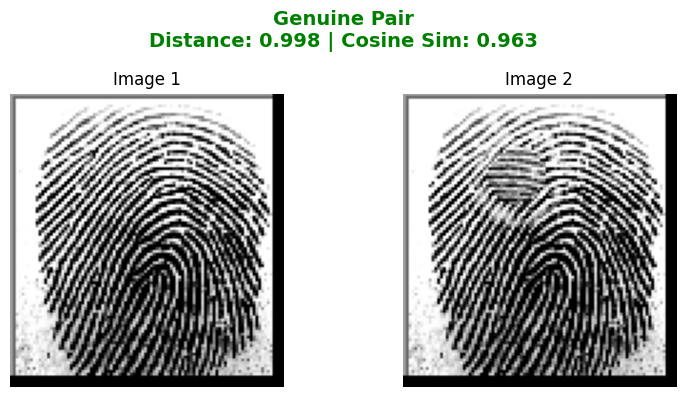

In [4]:
# Example 1: Genuine Pair (Subject 100 Left Index - Real vs Altered)
genuine_p1 = DATA_DIR / 'Real' / '100__M_Left_index_finger.BMP'
genuine_p2 = DATA_DIR / 'Altered' / 'Altered-Easy' / '100__M_Left_index_finger_CR.BMP'

fig_gen = compare_pair(genuine_p1, genuine_p2, is_genuine=True)
fig_gen.savefig(str(PROJECT_ROOT / 'data' / 'siamese_genuine_pair.png'), dpi=150, bbox_inches='tight')
plt.show()

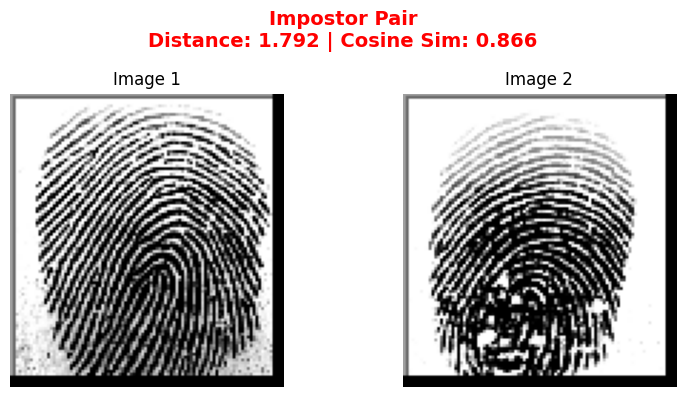

In [5]:
# Example 2: Impostor Pair (Subject 100 vs Subject 200)
impostor_p1 = DATA_DIR / 'Real' / '100__M_Left_index_finger.BMP'
impostor_p2 = DATA_DIR / 'Real' / '200__M_Left_index_finger.BMP'

fig_imp = compare_pair(impostor_p1, impostor_p2, is_genuine=False)
fig_imp.savefig(str(PROJECT_ROOT / 'data' / 'siamese_impostor_pair.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Embedding Dimensionality
We can inspect the actual 128-D vector produced by the network.

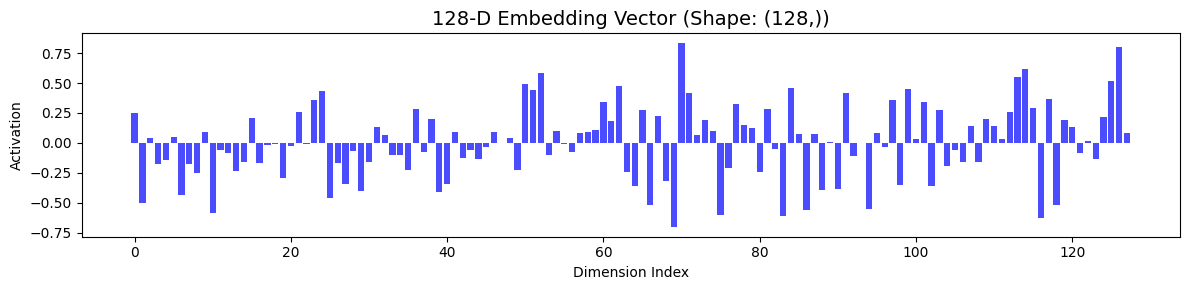

In [6]:
_, t1 = load_and_transform(genuine_p1)
emb = extract_embedding(model, t1, device)
vector = emb.cpu().numpy()[0]

plt.figure(figsize=(12, 3))
plt.bar(range(len(vector)), vector, color='blue', alpha=0.7)
plt.title(f"128-D Embedding Vector (Shape: {vector.shape})", fontsize=14)
plt.xlabel("Dimension Index")
plt.ylabel("Activation")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'siamese_embedding_vector.png'), dpi=150, bbox_inches='tight')
plt.show()